In [3]:
!pip install torchxrayvision

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 29.0/29.0 MB 64.9 MB/s eta 0:00:00:00:0100:01


In [4]:
import torch
from torchvision import datasets, transforms, models
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader
from torch.amp import autocast, GradScaler
import torchxrayvision as xrv

import matplotlib.pyplot as plt
import seaborn as sns

import os
import numpy as np
import pandas as pd

import pathlib
from PIL import Image

In [5]:
import pandas as pd
df = pd.read_csv('/kaggle/input/datasets/uyendang2404/nih-chest-balanced-split-v4/balanced_subsample.csv')

In [6]:
df.head()

,Image Index,Finding Labels,Follow-up #,Patient ID,Patient Age,Patient Gender,View Position,OriginalImage[Width,Height],OriginalImagePixelSpacing[x,y],Unnamed: 11,Target,Stratify_Key,Split
0,00009229_019.png,No Finding,19,9229,37,M,AP,2500,2048,0.168,0.168,NaN,No Finding,No FindingMAP,train
1,00003872_001.png,No Finding,1,3872,65,M,AP,2500,2048,0.168,0.168,NaN,No Finding,No FindingMAP,train
2,00020485_004.png,No Finding,4,20485,14,M,AP,2948,2216,0.139,0.139,NaN,No Finding,No FindingMAP,train
3,00010718_016.png,No Finding,16,10718,41,M,AP,2500,2048,0.168,0.168,NaN,No Finding,No FindingMAP,train
4,00014798_008.png,No Finding,8,14798,23,M,AP,2500,2048,0.168,0.168,NaN,No Finding,No FindingMAP,train


### --- 0. CONFIGURATION ---

In [7]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BATCH_SIZE = 64
LEARNING_RATE = 1e-4
NUM_EPOCHS = 20
Dense_CHECKPOINT_PATH = "/kaggle/working/xray_bias_dense_model.pth"

### --- 1. THE DATASET with metadata for bias analysis ---

In [8]:
from torch.utils.data import Dataset

class ChestXrayBiasDataset(Dataset):
    def __init__(self, dataframe, image_dir, transform=None):
        """
        Args:
            dataframe: The filtered dataframe (train_df, val_df, or test_df)
            image_dir: Path to the specific split folder (e.g., 'nih_split_data/train')
            transform: PyTorch transforms
        """
        self.df = dataframe.reset_index(drop=True)
        self.image_dir = image_dir
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        
        # Mapping 'Target' column to the actual subfolder names we created
        # Earlier we used 'Disease' and 'No Finding'
        subfolder = row['Target'] 
        img_path = os.path.join(self.image_dir, subfolder, row['Image Index'])
        img_index = row['Image Index']
        
        # Load image as Grayscale 'L'
        image = Image.open(img_path).convert('L') 

        # Create Binary Label: 1 for Disease, 0 for No Finding
        binary_label = 1.0 if row['Target'] == 'Disease' else 0.0
        label = torch.tensor(binary_label).float()
        
        # Bias features (Protected attributes)
        gender = 1.0 if row['Patient Gender'] == 'F' else 0.0
        position = 1.0 if row['View Position'] == 'AP' else 0.0

        if self.transform:
            image = self.transform(image)

        return image, label, gender, position, img_index

### --- 2. DATA PREPARATION ---

In [9]:
import cv2

def create_split_df(master_csv_path, split_folder_path, split_name):
    # Load your balanced csv (the one with 40k rows and 'Split' column)
    master_df = pd.read_csv(master_csv_path)
    
    # Filter by the split (train, val, or test)
    split_df = master_df[master_df['Split'] == split_name].copy()
    
    # Cross-reference with physical files to ensure no missing images
    physical_files = []
    for subfolder in ['Disease', 'No Finding']:
        path = os.path.join(split_folder_path, subfolder)
        if os.path.exists(path):
            physical_files.extend(os.listdir(path))
            
    # Keep only rows where the image actually exists in the folder
    final_df = split_df[split_df['Image Index'].isin(physical_files)]
    return final_df.reset_index(drop=True)

def medical_enhancement(img):
    img_np = np.array(img)
    clahe = cv2.createCLAHE(clipLimit=2.0,tileGridSize=(8,8))
    enhanced = clahe.apply(img_np)
    return enhanced
    
train_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.RandomResizedCrop(224),
    transforms.RandomRotation(10),
    transforms.Lambda(lambda img: medical_enhancement(img)),
    transforms.Lambda(lambda img: np.array(img)),
    transforms.Lambda(lambda img: xrv.datasets.normalize(img, 255)),
    transforms.Lambda(lambda img: img[None, :, :]),
    transforms.Lambda(lambda img: torch.from_numpy(img).float())
])
test_transform = transforms.Compose([
    transforms.Resize(256),
    transforms.CenterCrop(224),
    transforms.Lambda(lambda img: medical_enhancement(img)),
    transforms.Lambda(lambda img: np.array(img)),
    transforms.Lambda(lambda img: xrv.datasets.normalize(img, 255)),
    transforms.Lambda(lambda img: img[None, :, :]),
    transforms.Lambda(lambda img: torch.from_numpy(img).float())
])

### --- 3. MODEL INITIALIZATION (TorchXRayVision) ---


In [10]:
def get_model(model_type="densenet"):

    if model_type == "densenet":
        model = xrv.models.DenseNet(weights="densenet121-res224-all")

        # Freeze feature layers:
        for param in model.features.parameters():
            param.requires_grad = False
        # DenseNet uses .classifier
        num_ftrs = model.classifier.in_features
        
        model.classifier = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, 1))
    
        # Only unfreeze the final classifier layer
        for param in model.classifier[-1].parameters():
            param.requires_grad = True

    elif model_type == "resnet":
        model = xrv.models.ResNet(weights="resnet50-res512-all")
        # ResNet uses .model.fc
        num_ftrs = model.model.fc.in_features
        model.model.fc = nn.Sequential(
            nn.Dropout(0.2),
            nn.Linear(num_ftrs, 1))

    return model.to(DEVICE)

### --- 4. TRAINING FUNCTION ---

In [11]:
from torch.cuda.amp import autocast, GradScaler
from torch.optim.lr_scheduler import ReduceLROnPlateau

def train_model(model, train_loader, CHECKPOINT_PATH, epochs=10):
    """
    Master Training Function for Colab (T4 GPU Optimized)
    - Mixed Precision (autocast)
    - Best Model Saving
    - Comprehensive Metric Tracking
    """
    criterion = nn.BCEWithLogitsLoss()
    optimizer = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), 
                           lr=LEARNING_RATE,
                          weight_decay=1e-4)
    scaler = GradScaler() # Necessary for Mixed Precision to prevent underflow

    best_loss = float('inf')
    res = {
        'train_accuracy': [],
        'train_loss': []
    }

    print(f"Starting training on {DEVICE}...")

    for epoch in range(epochs):
        # --- TRAINING PHASE ---
        model.train()
        train_running_loss, train_correct, train_total = 0.0, 0, 0

        for imgs, lbls, _, _, _ in train_loader:
            imgs, lbls = imgs.to(DEVICE), lbls.to(DEVICE).view(-1, 1)

            optimizer.zero_grad()

            # Autocast handles the half-precision math on T4 Tensor Cores
            with autocast():
                outputs = model(imgs)
                loss = criterion(outputs, lbls)

            # Scaler handles the backward pass in Mixed Precision
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()

            # Stats calculation
            train_running_loss += loss.item()
            preds = (torch.sigmoid(outputs) > 0.5).float()
            train_correct += (preds == lbls).sum().item()
            train_total += lbls.size(0)


        # --- EPOCH SUMMARY ---
        epoch_train_loss = train_running_loss / len(train_loader)
        epoch_train_acc = train_correct / train_total

        print(f"Epoch {epoch+1}/{epochs} | "
              f"Loss: Train:{epoch_train_loss:.4f} | "
              f"Acc: Train:{epoch_train_acc:.3f}")

        # --- SAVE BEST MODEL ---
        if epoch_train_loss < best_loss:
            best_loss = epoch_train_loss
            torch.save(model.state_dict(), CHECKPOINT_PATH)
            print(f"⭐ Checkpoint saved to {CHECKPOINT_PATH}")

        # Store metrics for plotting
        res['train_accuracy'].append(epoch_train_acc)
        res['train_loss'].append(epoch_train_loss)

    # Load the best weights back into the model before finishing
    model.load_state_dict(torch.load(CHECKPOINT_PATH))
    print("Training Complete. Best weights loaded.")
    return res

### --- 5. BIAS EVALUATION ---


In [12]:
def evaluate_bias(model, test_loader, CHECKPOINT_PATH):
    model.load_state_dict(torch.load(CHECKPOINT_PATH))
    model.eval()
    data = []
    
    with torch.no_grad():
        # Looping through images, labels, and the two protected attributes
        for imgs, lbls, genders, positions, img_index in test_loader:
            imgs = imgs.to(DEVICE)
            
            # Generate binary predictions
            preds = (torch.sigmoid(model(imgs)) > 0.5).cpu().numpy().flatten()
            lbls_np = lbls.cpu().numpy().flatten()
            
            for i in range(len(preds)):
                data.append({
                    'img_index': img_index,
                    'Gender': 'Female' if genders[i] == 1 else 'Male',
                    'View': 'AP' if positions[i] == 1 else 'PA',
                    'True_Label': int(lbls_np[i]),
                    'Pred_Label': int(preds[i]),
                    'Correct': 1 if preds[i] == lbls_np[i] else 0
                })

    df = pd.DataFrame(data)
    
    print("\n--- ACCURACY BY GROUP ---")
    print(df.groupby(['Gender', 'View'])['Correct'].mean())
    
    return df

### ---6. SAVE and PLOT RESULTS---

In [13]:
def save_results(res, path):
    results_df = pd.DataFrame(res)
    results_df.to_csv(path, index=False)

# --- Plotting ---
def plot_bias(results_df, model_name):
    plt.figure(figsize=(10, 6))
    # CI=None removed for newer Seaborn versions, use errorbar=None
    sns.barplot(data=results_df, x='View', y='Correct', hue='Gender', errorbar=None)
    plt.title('Model Accuracy: Gender Bias across View Positions')
    plt.ylabel('Accuracy')
    plt.ylim(0, 1)
    plt.axhline(results_df['Correct'].mean(), color='red', linestyle='--', label='Global Avg')
    plt.legend()
    plt.savefig(f'/kaggle/working/{model_name}_bias.pdf')
    plt.show()

def plot_metrics(res, model_name):

    epochs = range(1, len(res['train_accuracy']) + 1)

    # ----- LOSS CURVE -----
    plt.figure()
    plt.plot(epochs, res['train_loss'], label='Training Loss')
    plt.plot(epochs, res['val_loss'], label='Validation Loss')
    plt.xlabel('Epoch')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # ----- ACCURACY CURVE -----
    plt.figure()
    plt.plot(epochs, res['train_accuracy'], label='Training Accuracy')
    plt.plot(epochs, res['val_accuracy'], label='Validation Accuracy')
    plt.xlabel('Epoch')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.savefig(f'/kaggle/working/{model_name}_performance.pdf')
    plt.show()

In [14]:
# 1. Setup DataFrames
path = '/kaggle/input/datasets/uyendang2404/nih-chest-balanced-split-v4/'
csv_path = path + 'balanced_subsample.csv'
train_path = path + 'sub_data/train'
test_path = path + 'sub_data/test'

train_df = create_split_df(csv_path, train_path, 'train')
test_df = create_split_df(csv_path, test_path, 'test')

# 2. Setup Loaders
train_loader = DataLoader(ChestXrayBiasDataset(train_df, train_path, train_transform), batch_size=BATCH_SIZE, shuffle=True)
test_loader = DataLoader(ChestXrayBiasDataset(test_df, test_path, test_transform), batch_size=BATCH_SIZE)

## EXECUTION

#### Train & Evaluate - DENSENET

In [ ]:
dense_model = get_model("densenet")
dense_model.op_threshs = None # Disable op_threshs for binary classification
densenet_res = train_model(dense_model, train_loader, Dense_CHECKPOINT_PATH, epochs=NUM_EPOCHS)

In [ ]:
dense_results_df = evaluate_bias(dense_model, test_loader, Dense_CHECKPOINT_PATH)
dense_results_df.to_csv('/kaggle/working/densenet_65k_df.csv', index=False)

In [17]:
model_path = '/kaggle/input/datasets/uyendang2404/dense-xray-model/xray_bias_dense_model.pth'
dense_model = get_model("densenet")
dense_model.op_threshs = None
dense_model.load_state_dict(torch.load(model_path, map_location=DEVICE))

dense_results_df = pd.read_csv('/kaggle/input/datasets/uyendang2404/dense-results-df/densenet_65k_df.csv')

In [18]:
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, classification_report

def plot_confusion_matrices(df):
    groups = df.groupby(['Gender', 'View'])
    fig, axes = plt.subplots(2, 2, figsize=(12, 10))
    axes = axes.flatten()

    for i, (name, group_df) in enumerate(groups):
        cm = confusion_matrix(group_df['True_Label'], group_df['Pred_Label'])
        sns.heatmap(cm, annot=True, fmt='d', ax=axes[i], cmap='Blues')
        axes[i].set_title(f'Group: {name}')
        axes[i].set_xlabel('Predicted')
        axes[i].set_ylabel('True')
    
    plt.tight_layout()
    plt.savefig('confusion_mx.png',dpi=300)
    plt.show()

In [19]:
from sklearn.metrics import confusion_matrix

def calculate_bias_metrics(df):
    results = []

    # 1. Define the different levels of aggregation
    # Combinations: (Gender, View), (Gender only), (View only)
    group_configs = [
        (['Gender', 'View'], "Specific"),
        (['Gender'], "By Gender"),
        (['View'], "By View")
    ]

    for columns, label in group_configs:
        groups = df.groupby(columns)

        for name, group_df in groups:
            # Flatten name if it's a tuple (for Gender/View combo) or keep as string
            group_name = " | ".join(name) if isinstance(name, tuple) else name

            # Confusion Matrix calculation
            tn, fp, fn, tp = confusion_matrix(group_df['True_Label'], group_df['Pred_Label']).ravel()

            tpr = tp / (tp + fn) if (tp + fn) > 0 else 0
            fpr = fp / (fp + tn) if (fp + tn) > 0 else 0
            acc = (tp + tn) / (tp + tn + fp + fn)

            results.append({
                'Category': label,
                'Group': group_name,
                'TPR': round(tpr, 3),
                'FPR': round(fpr, 3),
                'Accuracy': round(acc, 3),
                'Sample Size': len(group_df)
            })

    return pd.DataFrame(results)

metrics_df = calculate_bias_metrics(dense_results_df)
print(metrics_df)

    Category        Group    TPR    FPR  Accuracy  Sample Size
0   Specific  Female | AP  0.779  0.405     0.690         2658
1   Specific  Female | PA  0.575  0.212     0.682         2555
2   Specific    Male | AP  0.728  0.311     0.708         2365
3   Specific    Male | PA  0.613  0.244     0.683         2423
4  By Gender       Female  0.681  0.309     0.686         5213
5  By Gender         Male  0.668  0.278     0.695         4788
6    By View           AP  0.755  0.360     0.698         5023
7    By View           PA  0.594  0.227     0.683         4978


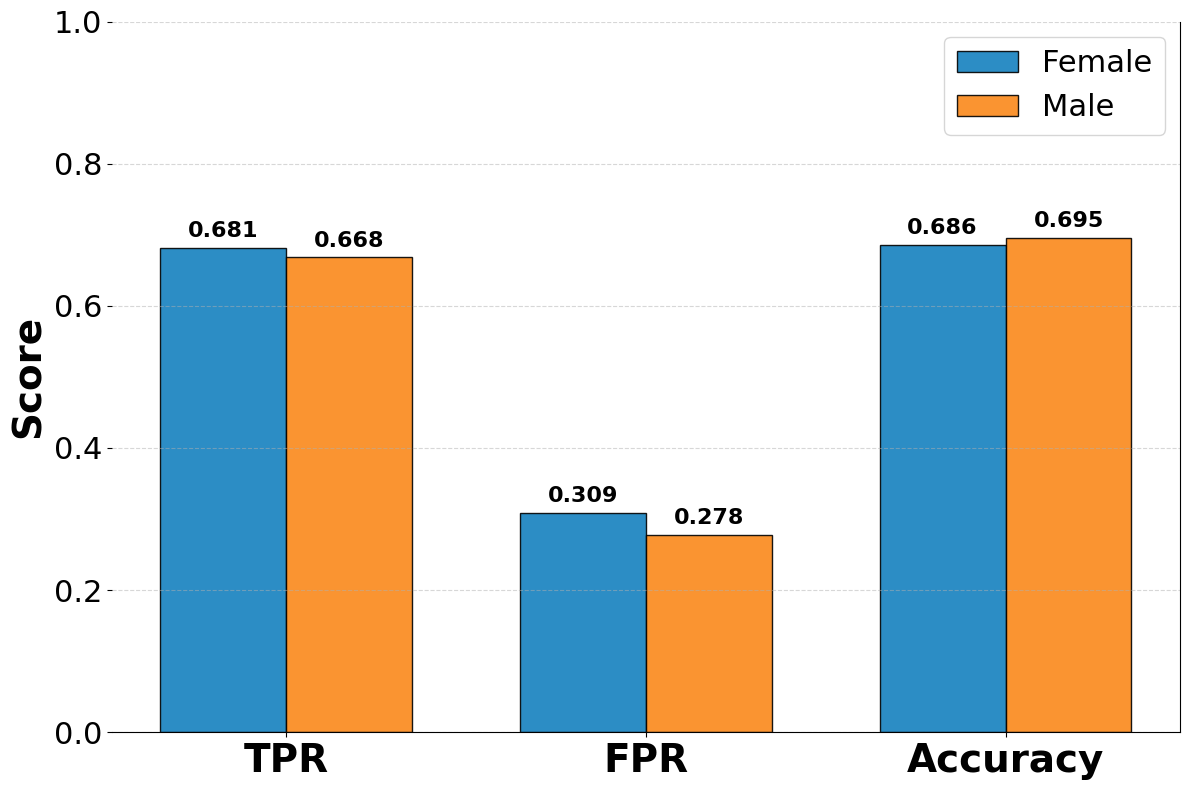

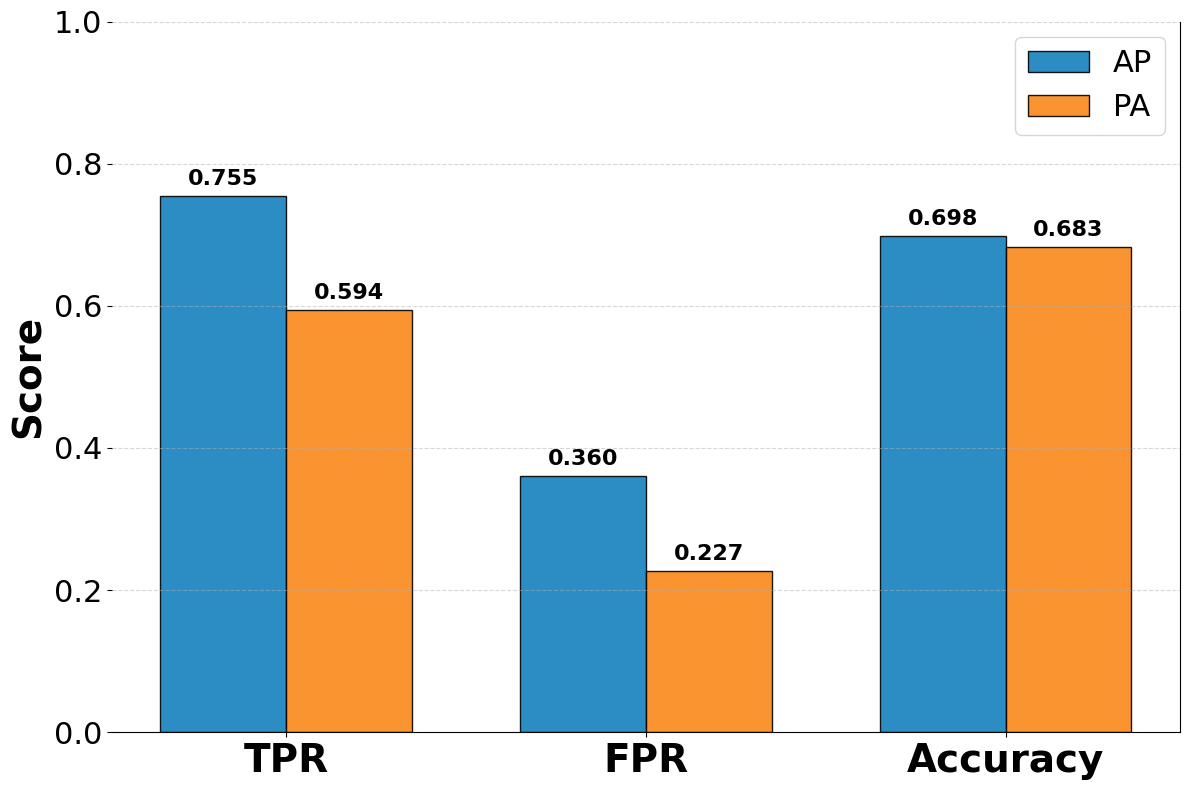

In [23]:
class_names = {0: "No Finding", 1: "Disease"}
def add_labels(ax, rects, fontsize=16):
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.3f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 5),
                    textcoords="offset points",
                    ha='center', va='bottom',
                    fontsize=fontsize, fontweight='bold')
        
def plot_separate_metrics(metrics_df, category_label):
    """Plots a single category of metrics with an internal legend."""
    df_subset = metrics_df[metrics_df['Category'] == category_label].reset_index()

    fig, ax = plt.subplots(figsize=(12, 8))

    metrics = ['TPR', 'FPR', 'Accuracy']
    x = np.arange(len(metrics))
    width = 0.35

    # Using the consistent color mapping we discussed
    colors = ['#1581BF', '#FA891A']

    for i, (idx, row) in enumerate(df_subset.iterrows()):
        rects = ax.bar(x + (i - 0.5) * width,
                        [row['TPR'], row['FPR'], row['Accuracy']],
                        width, label=row['Group'],
                        color=colors[i], alpha=0.9, edgecolor='black')
        add_labels(ax, rects)

    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=28, fontweight='bold')
    ax.tick_params(axis='y', labelsize=22)

    # Increase ylim to 1.3 to leave a clear gap for the internal legend
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score', fontsize=28, fontweight='bold')

    # Legend is now INSIDE the plot area
    # 'upper left' is usually safest as FPR (the middle bar) is often low
    ax.legend(loc='upper right', fontsize=22, frameon=True, framealpha=0.8)

    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)

    plt.tight_layout()

    save_path = f'/kaggle/working/{category_label}_metrics.pdf'
    plt.savefig(save_path) # Removed bbox_inches='tight' since legend is internal
    plt.show()

# Generate the plots
plot_separate_metrics(metrics_df, 'By Gender')
plot_separate_metrics(metrics_df, 'By View')

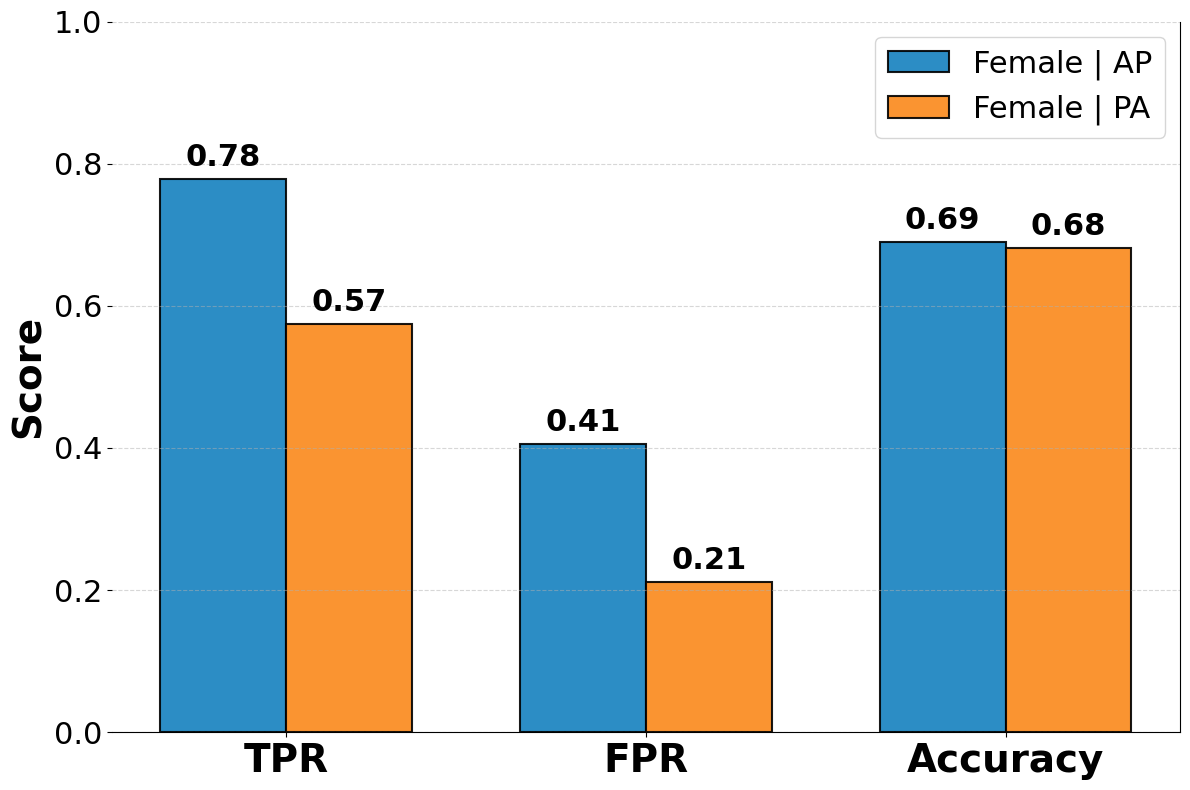

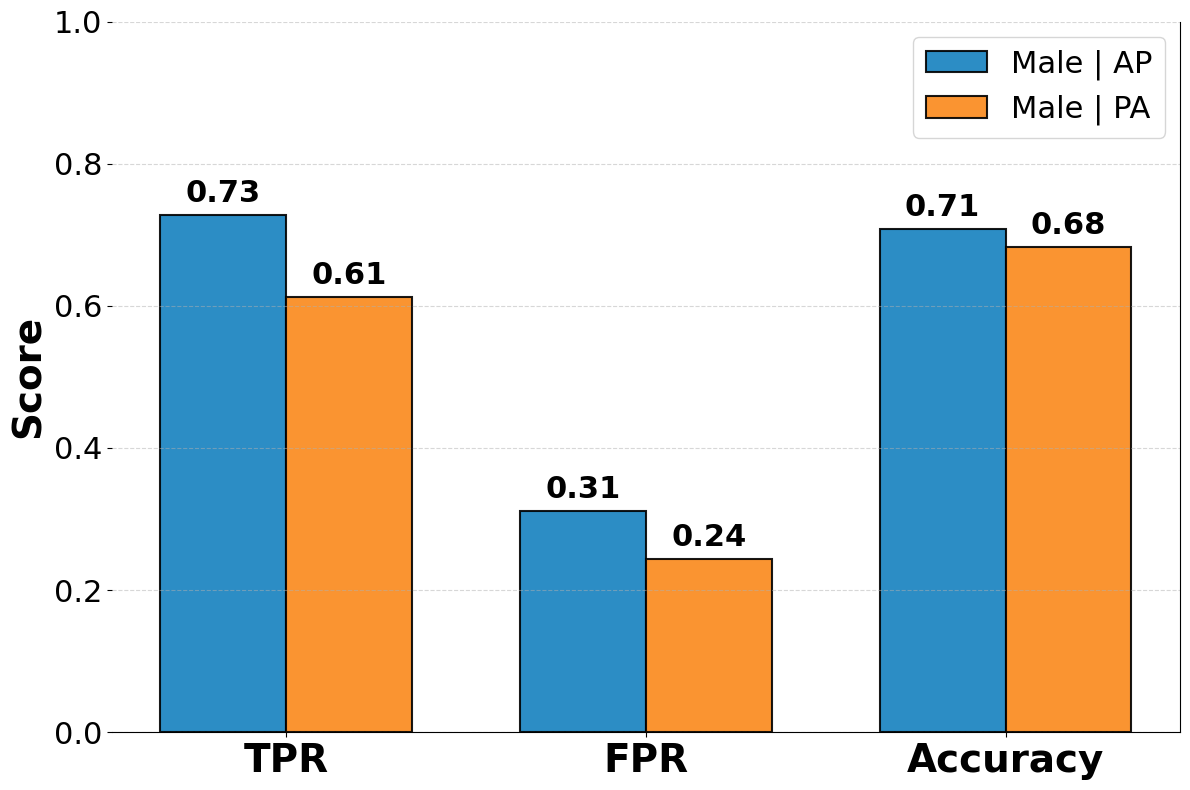

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Consistent color mapping: AP is Blue, PA is Orange
COLOR_MAP = {'AP': '#1581BF', 'PA': '#FA891A'}

def plot_stratified_bias(metrics_df, groups_to_compare, filename_prefix):
    """
    Plots stratified comparisons (e.g., Female AP vs PA) for poster presentation.
    """
    df_subset = metrics_df[metrics_df['Group'].isin(groups_to_compare)].reset_index()

    fig, ax = plt.subplots(figsize=(12, 8))
    metrics = ['TPR', 'FPR', 'Accuracy']
    x = np.arange(len(metrics))
    width = 0.35

    for i, (index, row) in enumerate(df_subset.iterrows()):
        # Extract the View from 'Female | AP' to get the correct color
        view_type = row['Group'].split('|')[-1].strip()
        current_color = COLOR_MAP.get(view_type, '#888888')

        pos = x + (i - 0.5) * width
        rects = ax.bar(pos, [row['TPR'], row['FPR'], row['Accuracy']],
                        width, label=row['Group'],
                        color=current_color, alpha=0.9, edgecolor='black', linewidth=1.5)

        # Add labels (2 decimal places is cleaner for posters)
        for rect in rects:
            height = rect.get_height()
            ax.annotate(f'{height:.2f}',
                        xy=(rect.get_x() + rect.get_width() / 2, height),
                        xytext=(0, 5), textcoords="offset points",
                        ha='center', va='bottom', fontsize=22, fontweight='bold')

    # Formatting for distance readability
    ax.set_xticks(x)
    ax.set_xticklabels(metrics, fontsize=28, fontweight='bold')
    ax.tick_params(axis='y', labelsize=22)
    ax.set_ylim(0, 1)
    ax.set_ylabel('Score', fontsize=28, fontweight='bold')

    # Legend at the top center
    ax.legend(loc='upper right', fontsize=22, frameon=True, framealpha=0.8)

    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.spines['top'].set_visible(False)
    ax.spines['left'].set_visible(False)
    plt.tight_layout()

    # Clean filename (removes spaces and pipes)
    clean_name = f"{filename_prefix}_metrics.pdf"
    save_path = f'/kaggle/working/{clean_name}'
    plt.savefig(save_path, bbox_inches='tight')
    plt.show()

# --- EXECUTION ---
# Using specific prefixes for the filenames used in your LaTeX \includegraphics
plot_stratified_bias(metrics_df, ['Female | AP', 'Female | PA'], 'Female_APPA')
plot_stratified_bias(metrics_df, ['Male | AP', 'Male | PA'], 'Male_APPA')

In [48]:
def get_batch(dataloader, idx):
    loader_iter = iter(dataloader)
    for i in range(idx + 1):
        batch = next(loader_iter)
    return batch


class_names = {0: "No Finding", 1: "Disease"}

def plot_predictions(model, dataloader, device, num_images=8, save_path=None):
    model.eval()
    images_shown = 0

    plt.figure(figsize=(12, 8))

    with torch.no_grad():
        batch = get_batch(dataloader, 12)

        images, labels, genders, positions, img_indices = batch

        images = images.to(device)
        labels = labels.to(device)

        outputs = model(images)
        probs = torch.sigmoid(outputs).view(-1)
        preds = (probs > 0.5).float()

        for i in range(images.size(0)):
            if images_shown == num_images:
                break

            img = images[i].cpu().squeeze()

            true_label = int(labels[i].item())
            pred_label = int(preds[i].item())
            prob = probs[i].item()

            gender = 'Female' if genders[i].item() == 1 else 'Male'
            view = 'AP' if positions[i].item() == 1 else 'PA'

            plt.subplot(1, num_images // 1, images_shown + 1)
            plt.imshow(img, cmap='gray')

            color = "green" if true_label == pred_label else "red"

            plt.title(
                f"Pred: {class_names[pred_label]} ({prob:.2f})\n"
                f"Ground Truth: {class_names[true_label]}\n"
                f"{gender}, {view}",
                fontsize=14,
                color=color
            )

            plt.axis('off')
            images_shown += 1

    plt.tight_layout()

    if save_path:
        plt.savefig(save_path, format='pdf', bbox_inches='tight')

    plt.show()

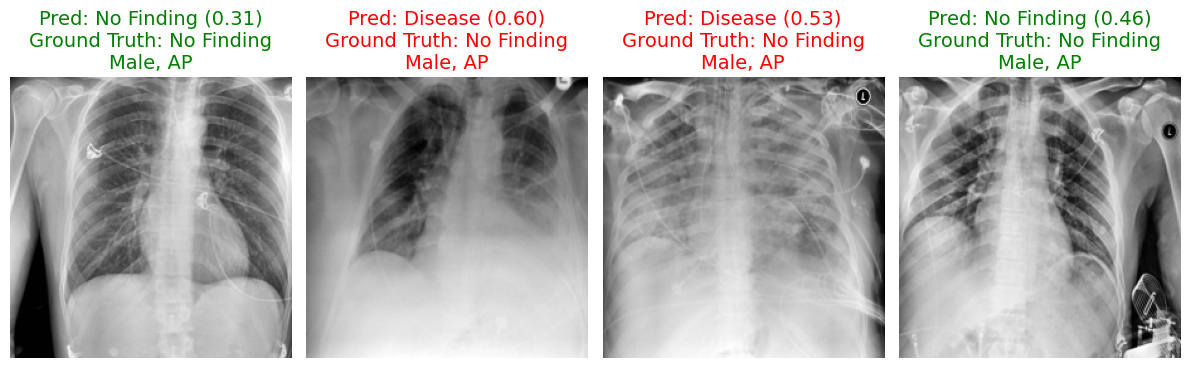

In [49]:
plot_predictions(dense_model, test_loader, DEVICE, num_images=4, save_path='/kaggle/working/predictions8.pdf')